<img src="https://github.com/ArchiColab/sitex/blob/main/images/banner.png?raw=1" width="1000"/>

# Program — POIs to Functional Group & Gehl Activity

**The question:** where does public life happen? Space Syntax (`03-NA01`) predicts from the
street network alone where people are likely to move. This notebook shows what is actually
there: shops, cafés, markets, schools and offices, sorted by the kind of activity they support
(Gehl, 2010):

- **Necessary:** what people *have to* do, whatever the street is like: buying food, going to
  school, visiting the health station.
- **Optional:** what people *choose* to do when the place invites them: a coffee, a walk, a
  browse through shops.
- **Social:** what people do *with others*: meeting, eating together, watching street life.

The objective of this notebook is to investigate where each kind of activity concentrates,
and to test the Space Syntax prediction against the places that are really there.

> Gehl, J. (2010). *Cities for People.* Island Press.

This notebook classifies every Overture place (POI) in the AOI by functional group
(e.g. Food & Drink, Healthcare) and Gehl activity type (Necessary / Optional / Social). It
uses a pre-built classification lookup, not the building footprints.

Which places are *public* amenities (a commune health station, a public school, a People's
Committee office) is not decided here. The category alone is too coarse for that: Overture
lists a veterinary clinic as `hospital` and a private clinic under the same category as a
public one. `03-NA03-Amenity_Isochrones.ipynb` decides it place by place, from the name.

The lookup is **place-independent**: it is keyed only by the Overture category
(`restaurant` → Food & Drink, whichever city the restaurant is in). It was built from
five Vietnamese cities (Pleiku, Can Tho, Da Nang, Hanoi and Ho Chi Minh City) to cover a
broad range of categories, not to limit which places can be classified. A category it has
not seen before still gets a functional group from the place's own Overture taxonomy path
(for example `shopping > food_and_beverage_store > ...` → Daily Needs & Grocery); only its
Gehl activity stays `Unclassified`. So any new AOI can be run safely.

**Overture taxonomy (since release 2026-09-23).** The category is Overture's
`taxonomy.primary`; the older `categories` column no longer exists. The lookup was
reviewed by hand under the old category names and carried over to the new ones by the
background notebook.

The notebook is optimized for Google Colab. Because it runs in the cloud, it can be used
on machines with limited computing power and in areas with limited bandwidth. It
downloads no data.

<img src="https://github.com/ArchiColab/sitex/blob/main/images/POIs_overview.svg?raw=1" width="1000"/>

**Library:** [`sitex`](https://github.com/ArchiColab/sitex). All the logic lives in
`sitex.arch.poi_classification`; this notebook only sets the parameters and calls the
functions. It uses plain table lookups, **no live LLM**.

**Requires (run first):** `00-Data-Acquisition.ipynb` (Section 10). The lookup is part of the
workshop data; it only has to be rebuilt when it is edited.

| Input | What it is |
|---|---|
| `data/overture/{slug}_places.gpkg` | This AOI's Overture places, from `00-Data-Acquisition.ipynb` (Section 10) |
| `data/overture/{slug}_buildings.gpkg` | The building footprints, drawn under the heatmaps in Section 7, also from `00-Data-Acquisition.ipynb` (Section 10) |
| `data/reference/overture_place_classification.json` | Every Overture category → functional group + Gehl activity, prepared in advance by the background notebook `00- Overture - Activities Classifier.ipynb` |

**Output (`data/overture/`):** `pois_classified_{slug}.geojson` (latitude/longitude, for web
maps) and `pois_classified_{slug}.gpkg` (local UTM, for analysis). They are read by
`03-NA03-Amenity_Isochrones.ipynb` and the `04-VIZ` maps.

---
## 1. Install & import
<img src="https://github.com/ArchiColab/sitex/blob/main/images/POIs_Setup.svg?raw=1" width="1000"/>

In [1]:
# One-time setup, if `sitex` isn't already installed in this kernel:
# %pip install "sitex[arch] @ git+https://github.com/ArchiColab/sitex.git"

import sys
import time
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
print("Running in:", "Google Colab" if IN_COLAB else "Local environment")

if IN_COLAB:
    %pip install "sitex[arch] @ git+https://github.com/ArchiColab/sitex.git"

    from google.colab import drive
    drive.mount("/content/gdrive")

    DATA_DIR = Path("/content/gdrive/MyDrive/Colab_Outputs")
    OUTPUT_DIR = Path("/content/gdrive/MyDrive/SiteX_Outputs")

    if not (DATA_DIR / "overture").is_dir():
        raise FileNotFoundError(
            f"{DATA_DIR} not found (or incomplete) in your Google Drive. "
            "Before the workshop: download the workshop data zip and unzip it into "
            "My Drive/Colab_Outputs -- see the workshop setup instructions."
        )
else:
    DATA_DIR = Path("..") / "data"
    OUTPUT_DIR = Path("..") / "outputs"

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

from sitex.core.config import CityConfig
from sitex.arch import poi_classification as poi

Running in: Local environment


## 2. Site configuration

Enter the same `place_name`, `local_lat`, `local_lon`, and `slug` you used in the
data-acquisition notebook. The `slug` must match the file names that notebook wrote to
`data/overture/` (default `pleiku`) — copy it exactly.
Any place that OpenStreetMap can find by name will work.

In [2]:
city = CityConfig(
    place_name="Phường Pleiku, Gia Lai, Vietnam",
    local_lat=13.9833,
    local_lon=108.0000,
    slug="pleiku",  # same SLUG as in 00-Data-Acquisition.ipynb
    data_dir=DATA_DIR,
    output_dir=OUTPUT_DIR,
)

print(f"AOI slug: {city.slug}")
print(f"Local EPSG (for the reprojected export in Section 6): {city.local_epsg}")

AOI slug: pleiku
Local EPSG (for the reprojected export in Section 6): 32649


---
## 3. Load the classification lookup
<img src="https://github.com/ArchiColab/sitex/blob/main/images/POIs_lookup.svg?raw=1" width="1000"/>

Each POI category carries two labels: its **functional group** (*what* the place is, e.g.
Healthcare) and its **Gehl activity** (Necessary / Optional / Social: *why* people go there,
which is about behavior).

In [3]:
#@title <font color=#1B7192> Click to run </font>  { display-mode: "form" }

_t0 = time.time()
print("### 3. Load the classification lookup ###", flush=True)

lookup = poi.load_classification_lookup_for_city(city)
print(f"{len(lookup):,} categories in the classification lookup")

print(f"--- 3. done in {time.time() - _t0:.2f}s ---\n")

### 3. Load the classification lookup ###


1,161 categories in the classification lookup
--- 3. done in 0.01s ---



---
## 4. Load places & classify
<img src="https://github.com/ArchiColab/sitex/blob/main/images/POIs_classify.svg?raw=1" width="1000"/>

In [4]:
#@title <font color=#1B7192> Click to run </font>  { display-mode: "form" }

_t0 = time.time()
print("### 4. Load places & classify ###", flush=True)

places = poi.load_places_for_aoi(city)
print(f"{len(places):,} places loaded for '{city.slug}'")

pois, missing = poi.classify_places(places, lookup)
if len(missing):
    print(f"{len(missing)} categories not in the reference table "
          "(functional group from their Overture taxonomy path, Gehl activity Unclassified):")
    print(missing.to_string())
else:
    print("Every category in this AOI is covered by the reference table.")

print(f"--- 4. done in {time.time() - _t0:.2f}s ---\n")

### 4. Load places & classify ###


3,562 places loaded for 'pleiku'


Every category in this AOI is covered by the reference table.
--- 4. done in 0.17s ---



C:\Users\Maddie\anaconda3\envs\gis\lib\site-packages\pyogrio\core.py:35: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


## 5. Gehl activity flags

A POI can support more than one Gehl activity. A café, for example, is both Optional
and Social. So each activity gets its own true/false flag, instead of forcing every POI
into a single category.

In [5]:
#@title <font color=#1B7192> Click to run </font>  { display-mode: "form" }

_t0 = time.time()
print("### 5. Gehl activity flags ###", flush=True)

pois = poi.add_gehl_activity_flags(pois)
pois_final = poi.select_final_columns(pois)

print(f"{len(pois_final):,} classified POIs\n")
print("—— Functional group ——")
print(pois_final["functional_group"].value_counts().to_string())
print(f"\nNecessary: {pois_final['is_necessary'].sum():,}  "
      f"Optional: {pois_final['is_optional'].sum():,}  "
      f"Social: {pois_final['is_social'].sum():,}")
print(f"Candidate third places (first-pass, review before trusting): "
      f"{pois_final['is_thirdspace'].sum():,} / {len(pois_final):,}")

print(f"--- 5. done in {time.time() - _t0:.2f}s ---\n")

### 5. Gehl activity flags ###


3,281 classified POIs

—— Functional group ——
functional_group
Food & Drink                        808
Retail & Shopping                   705
Business & Professional Services    645
Beauty & Personal Care              344
Accommodation & Travel              138
Healthcare                          129
Education                            95
Recreation & Sport                   90
Daily Needs & Grocery                88
Civic & Government                   43
Home & Garden Services               43
Community & Religion                 41
Pet Services                         41
Culture & Arts                       28
Agriculture & Industry               24
Utilities & Infrastructure           10
Automotive & Transport                9

Necessary: 2,109  Optional: 897  Social: 1,511
Candidate third places (first-pass, review before trusting): 1,041 / 3,281
--- 5. done in 0.02s ---



---
## 6. Map & export
<img src="https://github.com/ArchiColab/sitex/blob/main/images/POIs_export.svg?raw=1" width="1000"/>

The POIs are saved in two formats:

- **GeoJSON** stays in EPSG:4326 (latitude/longitude). This is the GeoJSON standard
  and what the web map needs.
- **GPKG** is reprojected to the local metric CRS (`city.local_epsg`), the same one used
  by the buildings and Space Syntax layers. Use this file for any spatial join,
  buffer, or distance calculation.

Don't use the GeoJSON for analysis. In latitude/longitude, distances are in degrees,
not meters, and joining it against the metric layers gives wrong or empty results.

In [6]:
poi.plot_pois_gehl_map(pois_final)

In [7]:
_t0 = time.time()
print("### 6. Export ###", flush=True)

geojson_path = poi.export_classified_pois_geojson_for_city(pois_final, city)
print(f"GeoJSON (WGS84)        → {geojson_path}")

gpkg_path = poi.export_classified_pois_gpkg_for_city(pois_final, city)
print(f"GPKG (EPSG:{city.local_epsg})    → {gpkg_path}")
print("Ready for the next phase: isochrone / service-area / accessibility analysis.")

print(f"--- 6. done in {time.time() - _t0:.2f}s ---\n")

### 6. Export ###


GeoJSON (WGS84)        → ..\data\overture\pois_classified_pleiku.geojson


GPKG (EPSG:32649)    → ..\data\overture\pois_classified_pleiku.gpkg
Ready for the next phase: isochrone / service-area / accessibility analysis.
--- 6. done in 0.29s ---



C:\Users\Maddie\anaconda3\envs\gis\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Cannot find tms_NZTM2000.json (GDAL_DATA is not defined)
  ogr_write(


---
## 7. Where does each activity concentrate?

**The main map of this notebook.** The point map in Section 6 shows every place; this one shows
where they *cluster*. Every classified place adds a soft glow around its location, and where
many places lie close together the glow gets stronger (a kernel density estimate, KDE). One
panel per activity, drawn over the building footprints:

- **Necessary** (blue), **Optional** (green), **Social** (orange).
- A place can support more than one activity (a café is both Optional and Social), so the
  same place can appear in more than one panel.

The heatmaps show where *places* for each activity cluster, not where people were observed:
they are a prediction to check on site. The third-place heatmap and the same maps made step by
step in QGIS are in the optional `04-VIZ-POIsHeatmaps.ipynb`.

### 7. Where does each activity concentrate? ###


C:\Users\Maddie\anaconda3\envs\gis\lib\site-packages\rasterio\env.py:664: RuntimeWarning: Cannot find gdalvrt.xsd (GDAL_DATA is not defined)
  elif GDALDataFinder().find_file("gdalvrt.xsd"):


Necessary (n=2,109)


Optional (n=897)


Social (n=1,511)
Saved -> ..\outputs\gehl_activities_heatmap_pleiku.png


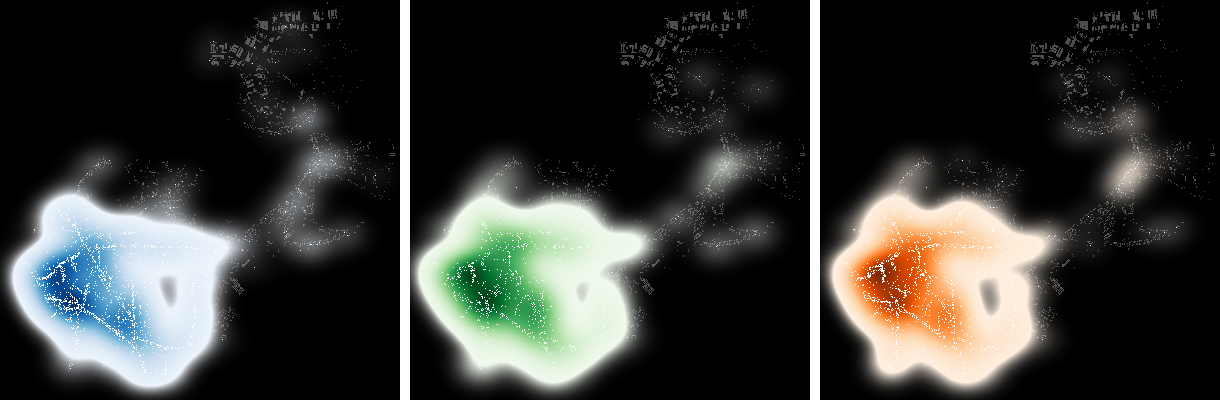

--- 7. done in 31.64s ---



In [8]:
#@title <font color=#1B7192> Click to run </font>  { display-mode: "form" }

_t0 = time.time()
print("### 7. Where does each activity concentrate? ###", flush=True)

import geopandas as gpd
from IPython.display import Image, display

from sitex.core.raster_viz import hstack_images, save_array_png
from sitex.viz import heatmaps as hm

GRID_SIZE = 400  # pixels per side: higher is finer, but slower

pois_local = pois_final.to_crs(city.local_epsg)
buildings = gpd.read_file(city.data_dir / "overture" / f"{city.slug}_buildings.gpkg").to_crs(pois_local.crs)

minx, miny, maxx, maxy = pois_local.total_bounds
pad_x, pad_y = (maxx - minx) * 0.07, (maxy - miny) * 0.07
XLIM = (minx - pad_x, maxx + pad_x)
YLIM = (miny - pad_y, maxy + pad_y)
buildings_clip = buildings.cx[XLIM[0]:XLIM[1], YLIM[0]:YLIM[1]]

GEHL_EVENTS = {"Necessary": ("is_necessary", "Blues"), "Optional": ("is_optional", "Greens"), "Social": ("is_social", "Oranges")}

panels = []
for activity, (flag_col, cmap) in GEHL_EVENTS.items():
    subset = pois_local[pois_local[flag_col]]
    rgba = hm.render_gehl_heatmap(subset, buildings_clip, XLIM, YLIM, cmap, grid_size=GRID_SIZE)
    panels.append(save_array_png(rgba, city.output_dir / f"_gehl_{flag_col}.png"))
    print(f"{activity} (n={len(subset):,})")

gehl_path = city.output_dir / f"gehl_activities_heatmap_{city.slug}.png"
hstack_images(panels, gehl_path)
print(f"Saved -> {gehl_path}")
display(Image(str(gehl_path)))

print(f"--- 7. done in {time.time() - _t0:.2f}s ---\n")

---
## 8. Field check: does the network predict the places?

**Two scales.** The heatmaps in Section 7 are smoothed over hundreds of metres: they show which
*part* of the ward has many places, not which street. For single streets, use the point map in
Section 6 (switch the activity layers on and off) next to the Choice and Reach maps of
[`03-NA01-SpaceSyntax_FieldTripIntro.ipynb`](03-NA01-SpaceSyntax_FieldTripIntro.ipynb). Choose an
area on the heatmap, then the streets inside it on the point map.

Before the field trip, pick 2–3 streets for each row:

| Pattern | What the models predict | What to check on the ground |
|---|---|---|
| High Choice + high Reach, **with** many Optional/Social points along it | Network and places agree: a lively street | Count open shopfronts and people lingering. Is it as lively as both maps say? |
| High Choice + high Reach, **with** few points | The network says "lively", but there are few places | Why? Blank walls, a gated compound, only housing, a new street not yet filled, or places Overture doesn't list? |
| Many points on a street with low Choice | Life without passing traffic | A market, a school gate, a pagoda: a destination that draws people by itself? |
| Mostly Necessary points, few Optional or Social | People come because they must | Do they stay? Is there anywhere to sit, any shade? |

**What to survey.** Walk 100 m of each street and record:

- every ground-floor unit, by type: shop / café or eatery / service / housing / blank wall /
  shuttered
- in two minutes: how many people stand or sit, and how many walk through
- street vendors, parked motorbikes and other uses of the footpath (Overture never lists them)
- the time of day: Necessary activities peak in the morning, Optional and Social ones often in
  the late afternoon and evening

*Example of a record:* "Street Z, inside the Optional hot area, many Optional points along it, Choice R800 high. 16:30, north side, 100 m:
14 units: 6 cafés and eateries, 3 shops, 2 services, 2 houses, 1 shuttered. In two minutes 23
people sitting, 11 walking through. 5 street vendors on the footpath, none of them in Overture."

This is the retail check of the field-trip Space Syntax notebook, now with the real places.

---
## Notes

- **`is_thirdspace` is a first-pass rule and has not been validated.** Check a sample
  of the flagged places on the map before using it in your analysis.
- **Another city?** Change the settings in Section 2; any place OpenStreetMap can find
  will work. The local coordinate system (UTM zone) is chosen automatically.

---
## When the model is wrong

Where your counts and the maps disagree, write down why. Common reasons:

- **Overture lists businesses, not street life.** Street vendors, morning markets, sidewalk
  cafés and informal repair stalls are missing, and in a Vietnamese street they are often most
  of the life.
- **Places close and move.** A listing can be years old; a shuttered shop still counts.
- **The label comes from the category.** A café where people work alone on laptops is counted
  as Social.
- **Density of listings is not density of people.** One big market hall is one point; ten small
  shops are ten.

Write one sentence per disagreement: *"The map says …, I found …, because …"*. Where the street
is livelier than the map, you have found the informal city the data doesn't see.

## Where to go next

| Next step | Open |
|---|---|
| Which public services (schools, health stations, markets) can people walk to? | [`03-NA03-Amenity_Isochrones.ipynb`](03-NA03-Amenity_Isochrones.ipynb) |
| Third places, and the same heatmaps made in QGIS (optional) | [`04-VIZ-POIsHeatmaps.ipynb`](04-VIZ-POIsHeatmaps.ipynb) |

**Into the design phase:** Optional and Social hot spots on high-Choice streets are the places
to strengthen with shade, seating and wider footpaths. High-Choice streets *without* activity are
where new ground-floor uses could go in your proposal.